# BrainInsight Final Training
EfficientNetB0 training pipeline for the 5-class MRI dataset.

## 1. Setup

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os, random, numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH="/content/drive/MyDrive/Brain-Insight/dataset_final"
MODEL_DIR="/content/drive/MyDrive/Brain-Insight/model_outputs"
os.makedirs(MODEL_DIR, exist_ok=True)
print(tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Build DataFrame

In [8]:
records=[]
exts=(".jpg",".jpeg",".png")
for label in sorted(os.listdir(DATASET_PATH)):
    for root,_,files in os.walk(os.path.join(DATASET_PATH,label)):
        for f in files:
            if f.lower().endswith(exts):
                records.append((os.path.join(root,f),label))
df=pd.DataFrame(records,columns=["filepath","label"])
print(df["label"].value_counts())

label
alzheimer             4500
tumor                 4200
multiple_sclerosis    1411
normal                1400
stroke                 756
Name: count, dtype: int64


## 3. Train / Validation Split

In [9]:
train_df,val_df=train_test_split(
    df,test_size=0.2,stratify=df["label"],random_state=SEED)

classes=sorted(train_df["label"].unique())
label_to_idx={c:i for i,c in enumerate(classes)}

weights=compute_class_weight(
    class_weight="balanced",
    classes=np.array(classes),
    y=train_df["label"]
)
class_weights={label_to_idx[c]:float(w) for c,w in zip(classes,weights)}
print(class_weights)

{0: 0.5451666666666667, 1: 1.7398936170212767, 2: 1.7523214285714286, 3: 3.2439669421487602, 4: 0.5841071428571428}


## 4. tf.data Pipeline

In [10]:
IMG_SIZE=(224,224)
BATCH_SIZE=32

augment=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
])

def load_image(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_jpeg(img,channels=3)
    img=tf.image.resize(img,IMG_SIZE)
    img=preprocess_input(img)
    return img, tf.one_hot(label_to_idx[label.numpy().decode()], depth=len(classes))

def tf_load(path,label):
    img,lbl=tf.py_function(load_image,[path,label],[tf.float32,tf.float32])
    img.set_shape((224,224,3))
    lbl.set_shape((len(classes),))
    return img,lbl

train_ds=tf.data.Dataset.from_tensor_slices((train_df.filepath.values,train_df.label.values))
train_ds=train_ds.shuffle(len(train_df),seed=SEED).map(tf_load,num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds=tf.data.Dataset.from_tensor_slices((val_df.filepath.values,val_df.label.values))
val_ds=val_ds.map(tf_load,num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


## 5. Model

In [11]:
base=EfficientNetB0(weights="imagenet",include_top=False,input_shape=(224,224,3))
base.trainable=False

inputs=layers.Input((224,224,3))
x=augment(inputs)
x=base(x,training=False)
x=layers.GlobalAveragePooling2D()(x)
x=layers.BatchNormalization()(x)
x=layers.Dropout(0.4)(x)
outputs=layers.Dense(len(classes),activation="softmax")(x)
model=Model(inputs,outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,096 (15.49 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 6. Train

In [12]:
callbacks=[
    EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss",factor=0.2,patience=2),
    ModelCheckpoint(
        os.path.join(MODEL_DIR,"BrainInsight_Final.keras"),
        save_best_only=True,
        monitor="val_loss")
]

history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1149s 4s/step - accuracy: 0.8918 - loss: 0.3928 - val_accuracy: 0.9625 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 336ms/step - accuracy: 0.9506 - loss: 0.1733 - val_accuracy: 0.9760 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 337ms/step - accuracy: 0.9557 - loss: 0.1593 - val_accuracy: 0.9784 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 335ms/step - accuracy: 0.9607 - loss: 0.1290 - val_accuracy: 0.9800 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 104s 340ms/step - accuracy: 0.9662 - loss: 0.1242 - val_accuracy: 0.9845 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 143s 342ms/step - accuracy: 0.9653 - loss: 0.1210 - val_accuracy: 0.9894 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 335ms/step - accuracy

## 7. Fine Tune

In [13]:
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 123s 351ms/step - accuracy: 0.9157 - loss: 0.2653 - val_accuracy: 0.9780 - val_loss: 0.0836 - learning_rate: 1.0000e-05
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 336ms/step - accuracy: 0.9361 - loss: 0.1922 - val_accuracy: 0.9792 - val_loss: 0.0838 - learning_rate: 1.0000e-05
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 335ms/step - accuracy: 0.9472 - loss: 0.1755 - val_accuracy: 0.9792 - val_loss: 0.0823 - learning_rate: 2.0000e-06
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 142s 335ms/step - accuracy: 0.9506 - loss: 0.1687 - val_accuracy: 0.9808 - val_loss: 0.0780 - learning_rate: 2.0000e-06
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 334ms/step - accuracy: 0.9470 - loss: 0.1622 - val_accuracy: 0.9808 - val_loss: 0.0781 - learning_rate: 4.0000e-07


In [14]:
import os

print(os.listdir(MODEL_DIR))

['BrainInsight_Final.keras']


In [15]:
from tensorflow.keras.models import load_model
import os

model = load_model(os.path.join(MODEL_DIR, "BrainInsight_Final.keras"))

print("Best model loaded successfully!")

Best model loaded successfully!


In [17]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,079,028 (15.56 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 17,932 (70.05 KB)

In [18]:
base = model.get_layer("efficientnetb0")

base.trainable = True

# Freeze all except the last 30 layers
for layer in base.layers[:-30]:
    layer.trainable = False

print("Trainable layers:", sum([layer.trainable for layer in base.layers]))

Trainable layers: 30


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 126s 355ms/step - accuracy: 0.9143 - loss: 0.2755 - val_accuracy: 0.9772 - val_loss: 0.0843 - learning_rate: 1.0000e-05
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 335ms/step - accuracy: 0.9400 - loss: 0.1956 - val_accuracy: 0.9804 - val_loss: 0.0792 - learning_rate: 1.0000e-05
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 105s 343ms/step - accuracy: 0.9477 - loss: 0.1674 - val_accuracy: 0.9813 - val_loss: 0.0765 - learning_rate: 2.0000e-06
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 104s 337ms/step - accuracy: 0.9477 - loss: 0.1747 - val_accuracy: 0.9817 - val_loss: 0.0755 - learning_rate: 2.0000e-06
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 104s 339ms/step - accuracy: 0.9526 - loss: 0.1592 - val_accuracy: 0.9813 - val_loss: 0.0758 - learning_rate: 4.0000e-07


In [21]:
model.save(os.path.join(MODEL_DIR, "BrainInsight_FineTuned.keras"))

That way you have:

BrainInsight_Final.keras → best transfer-learning model (recommended for deployment)(98.94% Validation Accuracy
0.0394 Validation Loss)
BrainInsight_FineTuned.keras → experimental fine-tuned model(98.13%)

## 8. Evaluation

Step 1️⃣ Evaluate the Best Model

In [22]:
from tensorflow.keras.models import load_model
import os

model = load_model(os.path.join(MODEL_DIR, "BrainInsight_Final.keras"))

Step 2️⃣ Evaluate Accuracy

In [23]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

77/77 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.9894 - loss: 0.0394
Validation Loss : 0.039431557059288025
Validation Accuracy : 0.9894050359725952


Step 3️⃣ Classification Report

In [24]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

                    precision    recall  f1-score   support

         alzheimer       1.00      1.00      1.00       900
multiple_sclerosis       0.98      0.99      0.99       283
            normal       0.96      0.95      0.96       280
            stroke       0.99      1.00      0.99       151
             tumor       0.99      0.99      0.99       840

          accuracy                           0.99      2454
         macro avg       0.98      0.99      0.99      2454
      weighted avg       0.99      0.99      0.99      2454



Step 4️⃣ Confusion Matrix

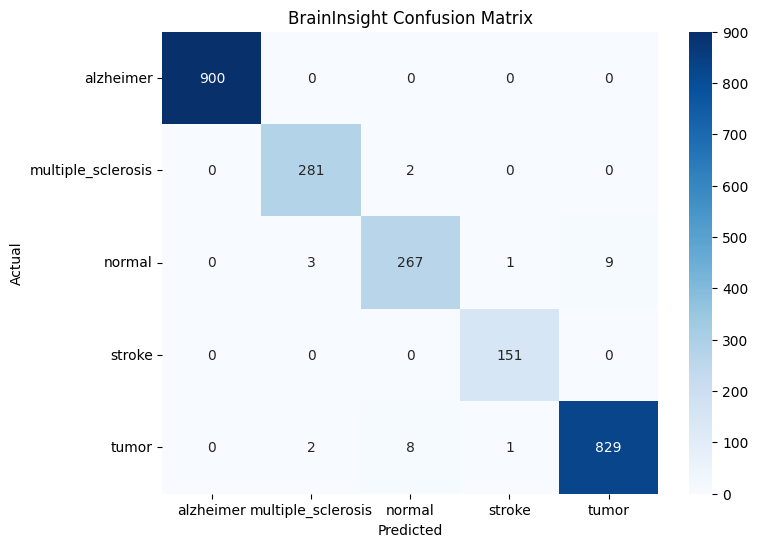

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BrainInsight Confusion Matrix")

plt.show()

Step 5️⃣ Training Graphs

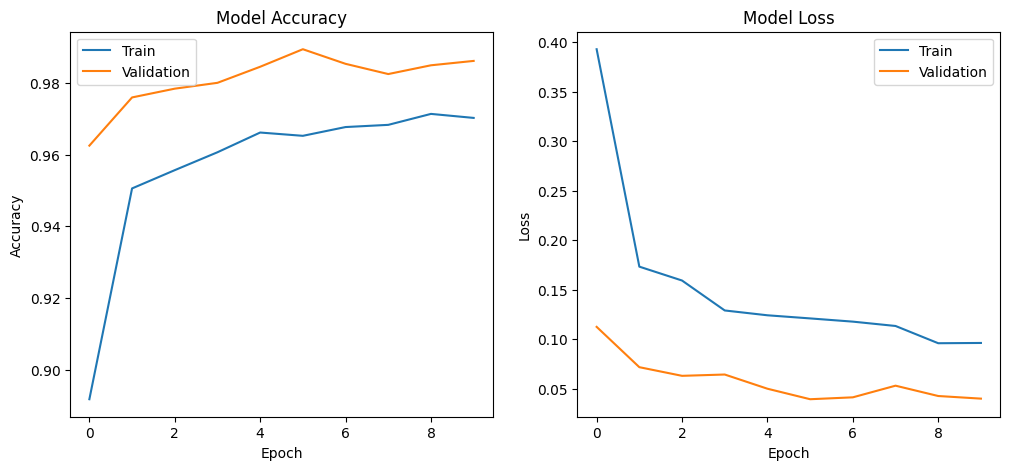

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()